In [2]:
import pandas as pd
from pathlib import Path
from glob import glob
from sklearn.model_selection import train_test_split

pd.set_option('display.max_columns',None)
pd.set_option('display.max_colwidth',None)

ROOT=Path("/home/xiong/Downloads")
#list(ROOT.glob("*"))



In [3]:
#train is the concatenation of fake and true
train=pd.read_csv(ROOT/"train.csv")
fake=pd.read_csv(ROOT/"fake.csv")
true=pd.read_csv(ROOT/"true.csv")


train["date"]=train["date"].str.strip()
train["date"]=pd.to_datetime(train["date"],format='mixed')

In [4]:
train["subject"]=pd.Categorical(train["subject"])

In [5]:
import nltk
from nltk.corpus import stopwords

titles=[]
for word in train["title"]:
    tokens=nltk.word_tokenize(word)
    porter=nltk.PorterStemmer()
    titles.append(" ".join([porter.stem(token) for token in tokens]))

texts=[]
train_=train[train["text"].notna()]
for text in train_["text"]:
    tokens=nltk.word_tokenize(text)
    porter=nltk.PorterStemmer()
    texts.append(" ".join([porter.stem(token) for token in tokens]))



In [6]:
stop_words=stopwords.words('english')
for w in ['!',',','.','?','-s','-ly','</s>','s',':','，','@']:
    stop_words.append(w)
title_final=[]
for i in titles:
    tokens=nltk.word_tokenize(i)
    title_final.append(" ".join([x for x in tokens if x not in stop_words]))
text_final=[]
for i in texts:
    tokens=nltk.word_tokenize(i)
    text_final.append(" ".join([x for x in tokens if x not in stop_words]))

train["title"]=title_final
train.loc[train["text"].notna(),"text"]=text_final

In [78]:
train.to_csv(ROOT/"train_0104.csv",index=False)

In [7]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import Tokenizer,Word2Vec

spark=SparkSession.builder.master("local").appName("news").getOrCreate()
train=spark.createDataFrame(train)

25/01/09 17:10:44 WARN Utils: Your hostname, xiong-PC resolves to a loopback address: 127.0.1.1; using 192.168.31.180 instead (on interface wlp1s0)
25/01/09 17:10:44 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/01/09 17:10:44 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [8]:
x_train_title=train.select(["lable","title"])
title_tokenizer=Tokenizer(inputCol="title",outputCol="words")
x_train_title_token=title_tokenizer.transform(x_train_title)
x_train_title_token.show()

25/01/09 17:10:54 WARN TaskSetManager: Stage 0 contains a task of very large size (74226 KiB). The maximum recommended task size is 1000 KiB.
25/01/09 17:10:57 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


+-----+--------------------+--------------------+
|lable|               title|               words|
+-----+--------------------+--------------------+
|    1|u.s. budget fight...|[u.s., budget, fi...|
|    1|u.s. militari acc...|[u.s., militari, ...|
|    1|senior u.s. repub...|[senior, u.s., re...|
|    1|fbi russia probe ...|[fbi, russia, pro...|
|    1|trump want postal...|[trump, want, pos...|
|    1|white hou congres...|[white, hou, cong...|
|    1|trump say russia ...|[trump, say, russ...|
|    1|factbox trump twi...|[factbox, trump, ...|
|    1|trump twitter ( d...|[trump, twitter, ...|
|    1|alabama offici ce...|[alabama, offici,...|
|    1|jone certifi u.s....|[jone, certifi, u...|
|    1|new york governor...|[new, york, gover...|
|    1|factbox trump twi...|[factbox, trump, ...|
|    1|trump twitter ( d...|[trump, twitter, ...|
|    1|man say deliv man...|[man, say, deliv,...|
|    1|virginia offici p...|[virginia, offici...|
|    1|u.s. lawmak quest...|[u.s., lawmak, qu...|


25/01/09 17:10:58 WARN PythonRunner: Detected deadlock while completing task 0.0 in stage 0 (TID 0): Attempting to kill Python Worker


In [9]:
title_w2v=Word2Vec(vectorSize=20,minCount=1,inputCol="words",outputCol="w2v")
title_w2v_model=title_w2v.fit(x_train_title_token)
x_train_title_w2v=title_w2v_model.transform(x_train_title_token)
#pandasdf=x_train_title_w2v.toPandas()
#pandasdf_=pandasdf.drop(columns=["title","words"])
x_train_title_w2v.show()

25/01/09 17:11:02 WARN TaskSetManager: Stage 1 contains a task of very large size (74226 KiB). The maximum recommended task size is 1000 KiB.
25/01/09 17:11:04 WARN TaskSetManager: Stage 3 contains a task of very large size (74226 KiB). The maximum recommended task size is 1000 KiB.
25/01/09 17:11:05 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS
25/01/09 17:11:09 WARN TaskSetManager: Stage 6 contains a task of very large size (74226 KiB). The maximum recommended task size is 1000 KiB.


+-----+--------------------+--------------------+--------------------+
|lable|               title|               words|                 w2v|
+-----+--------------------+--------------------+--------------------+
|    1|u.s. budget fight...|[u.s., budget, fi...|[0.00394562585279...|
|    1|u.s. militari acc...|[u.s., militari, ...|[-0.0746063764340...|
|    1|senior u.s. repub...|[senior, u.s., re...|[0.10400350801646...|
|    1|fbi russia probe ...|[fbi, russia, pro...|[0.08445111243054...|
|    1|trump want postal...|[trump, want, pos...|[-0.0652858840508...|
|    1|white hou congres...|[white, hou, cong...|[-0.0363390639956...|
|    1|trump say russia ...|[trump, say, russ...|[0.08973941626027...|
|    1|factbox trump twi...|[factbox, trump, ...|[0.26304348321123...|
|    1|trump twitter ( d...|[trump, twitter, ...|[0.23551999405026...|
|    1|alabama offici ce...|[alabama, offici,...|[0.16990542991293...|
|    1|jone certifi u.s....|[jone, certifi, u...|[0.18887566612102...|
|    1

25/01/09 17:11:13 WARN PythonRunner: Detected deadlock while completing task 0.0 in stage 6 (TID 6): Attempting to kill Python Worker


In [10]:
x_train_title_w2v_=x_train_title_w2v.drop("title").drop("words")
x_train_title_w2v_1=x_train_title_w2v_.withColumn("label_int",x_train_title_w2v_["lable"].cast('int')).drop("lable")
x_train_title_w2v_1.printSchema()

root
 |-- w2v: vector (nullable = true)
 |-- label_int: integer (nullable = true)



In [11]:
x_train_text=train.select(["lable","text"])
text_tokenizer=Tokenizer(inputCol="text",outputCol="words")
x_train_text_token=text_tokenizer.transform(x_train_text)
x_train_text_token.show()

25/01/09 17:12:11 WARN TaskSetManager: Stage 7 contains a task of very large size (74226 KiB). The maximum recommended task size is 1000 KiB.


+-----+--------------------+--------------------+
|lable|                text|               words|
+-----+--------------------+--------------------+
|    1|washington ( reut...|[washington, (, r...|
|    1|washington ( reut...|[washington, (, r...|
|    1|washington ( reut...|[washington, (, r...|
|    1|washington ( reut...|[washington, (, r...|
|    1|seattle/washingto...|[seattle/washingt...|
|    1|west palm beach f...|[west, palm, beac...|
|    1|west palm beach f...|[west, palm, beac...|
|    1|follow statement ...|[follow, statemen...|
|    1|follow statement ...|[follow, statemen...|
|    1|washington ( reut...|[washington, (, r...|
|    1|( reuter ) - alab...|[(, reuter, ), -,...|
|    1|new york/washingt...|[new, york/washin...|
|    1|follow statement ...|[follow, statemen...|
|    1|follow statement ...|[follow, statemen...|
|    1|( dec. 25 stori s...|[(, dec., 25, sto...|
|    1|( reuter ) - lott...|[(, reuter, ), -,...|
|    1|washington ( reut...|[washington, (, r...|


25/01/09 17:12:15 WARN PythonRunner: Detected deadlock while completing task 0.0 in stage 7 (TID 7): Attempting to kill Python Worker


In [12]:
text_w2v=Word2Vec(vectorSize=20,minCount=1,inputCol="words",outputCol="w2v")
text_w2v_model=text_w2v.fit(x_train_text_token)

25/01/09 17:12:19 WARN TaskSetManager: Stage 8 contains a task of very large size (74226 KiB). The maximum recommended task size is 1000 KiB.
25/01/09 17:12:24 WARN TaskSetManager: Stage 10 contains a task of very large size (74226 KiB). The maximum recommended task size is 1000 KiB.


In [13]:
x_train_text_w2v=text_w2v_model.transform(x_train_text_token)
x_train_text_w2v_1=x_train_text_w2v.drop("text").drop("words")
x_train_text_w2v_2=x_train_text_w2v_1.withColumn("label_int",x_train_text_w2v_1["lable"].cast('int')).drop("lable")
x_train_text_w2v_2.printSchema()

root
 |-- w2v: vector (nullable = true)
 |-- label_int: integer (nullable = true)



In [14]:
text_train_df=x_train_text_w2v_2.toPandas()
title_train_df=x_train_title_w2v_1.toPandas()


25/01/09 17:14:45 WARN TaskSetManager: Stage 13 contains a task of very large size (74226 KiB). The maximum recommended task size is 1000 KiB.
25/01/09 17:14:49 WARN TaskSetManager: Stage 14 contains a task of very large size (74226 KiB). The maximum recommended task size is 1000 KiB.


In [ ]:
from pyspark.ml.linalg import DenseVector
concat_train=[]
for i,j in zip(title_train_df["w2v"],text_train_df["w2v"]):
    concat_train.append(DenseVector(list(i)+list(j)))

pddf_train=title_train_df.copy()
pddf_train["w2v"]=concat_train
spdf_train=spark.createDataFrame(pddf_train)
spdf_train.show()

+--------------------+---------+
|                 w2v|label_int|
+--------------------+---------+
|[0.00394562585279...|        1|
|[-0.0746063764340...|        1|
|[0.10400350801646...|        1|
|[0.08445111243054...|        1|
|[-0.0652858840508...|        1|
|[-0.0363390639956...|        1|
|[0.08973941626027...|        1|
|[0.26304348321123...|        1|
|[0.23551999405026...|        1|
|[0.16990542991293...|        1|
|[0.18887566612102...|        1|
|[0.12578290711098...|        1|
|[0.29193775790433...|        1|
|[0.27635823264718...|        1|
|[0.09508632719516...|        1|
|[0.10168242025085...|        1|
|[0.15762645854718...|        1|
|[0.29923920527411...|        1|
|[0.12976830059455...|        1|
|[0.04388471253914...|        1|
+--------------------+---------+
only showing top 20 rows



25/01/09 17:15:05 WARN TaskSetManager: Stage 15 contains a task of very large size (16450 KiB). The maximum recommended task size is 1000 KiB.


In [ ]:
from sklearn.manifold import TSNE
import numpy as np

ts=TSNE(n_components=2)
train_embedded=ts.fit_transform(np.array(concat_train))
vec_2=pd.DataFrame(train_embedded)
pddf_train_vec_2=pd.concat([pddf_train["label_int"],vec_2],axis=1)
pddf_train_vec_2.columns=["label","x_dim","y_dim"]


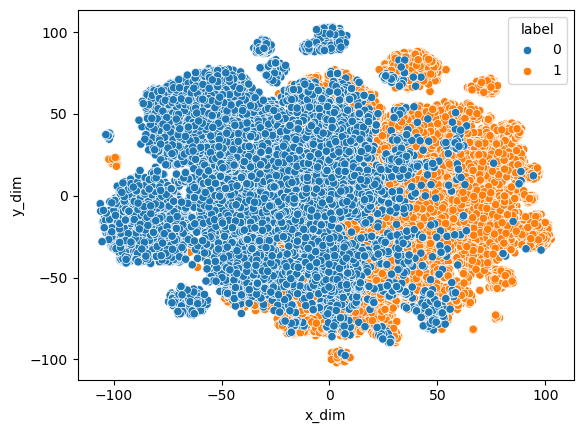

In [ ]:
import seaborn as sns

sns.scatterplot(data=pddf_train_vec_2,x="x_dim",y="y_dim",hue="label");

In [ ]:
#convert the list into columns
pddf_train_vec=pd.concat([pddf_train["label_int"],pd.DataFrame(pddf_train["w2v"].tolist())],axis=1)

sns.pairplot(data=pddf_train_vec,hue="label_int")


In [32]:
X=pd.DataFrame(pddf_train["w2v"].tolist())
y=pddf_train["label_int"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.33,random_state=42)



In [34]:
from sklearn.linear_model import LogisticRegression
lrm=LogisticRegression(random_state=0).fit(X_train,y_train)
y_prediction=lrm.predict(X_test)

In [36]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_prediction)

0.965370595382746